[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/6_1_using_word_embeddings_UPDATED_SmallData.ipynb)

# Using word embeddings

This notebook contains the second code sample found in Chapter 6, Section 1 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

---


Another popular and powerful way to associate a vector with a word is the use of dense "word vectors", also called "word embeddings".
While the vectors obtained through one-hot encoding are binary, sparse (mostly made of zeros) and very high-dimensional (same dimensionality as the
number of words in the vocabulary), "word embeddings" are low-dimensional floating point vectors
(i.e. "dense" vectors, as opposed to sparse vectors).
Unlike word vectors obtained via one-hot encoding, word embeddings are learned from data.
It is common to see word embeddings that are 256-dimensional, 512-dimensional, or 1024-dimensional when dealing with very large vocabularies.
On the other hand, one-hot encoding words generally leads to vectors that are 20,000-dimensional or higher (capturing a vocabulary of 20,000
token in this case). So, word embeddings pack more information into far fewer dimensions.

In [ ]:
import keras
keras.__version__

'2.9.0'

In [ ]:
# The data below is downloaded from public sources (Stanford), so no Google Drive is needed.
# (Only mount Drive if you want to save your trained model there:)
# from google.colab import drive
# drive.mount('/content/drive')

![word embeddings vs. one hot encoding](https://s3.amazonaws.com/book.keras.io/img/ch6/word_embeddings.png)

There are two ways to obtain word embeddings:

* Learn word embeddings jointly with the main task you care about (e.g. document classification or sentiment prediction).
In this setup, you would start with random word vectors, then learn your word vectors in the same way that you learn the weights of a neural network.
* Load into your model word embeddings that were pre-computed using a different machine learning task than the one you are trying to solve.
These are called "pre-trained word embeddings".

Let's take a look at both.

## Learning word embeddings with the `Embedding` layer


The simplest way to associate a dense vector to a word would be to pick the vector at random. The problem with this approach is that the
resulting embedding space would have no structure: for instance, the words "accurate" and "exact" may end up with completely different
embeddings, even though they are interchangeable in most sentences. It would be very difficult for a deep neural network to make sense of
such a noisy, unstructured embedding space.

To get a bit more abstract: the geometric relationships between word vectors should reflect the semantic relationships between these words.
Word embeddings are meant to map human language into a geometric space. For instance, in a reasonable embedding space, we would expect
synonyms to be embedded into similar word vectors, and in general we would expect the geometric distance (e.g. L2 distance) between any two
word vectors to relate to the semantic distance of the associated words (words meaning very different things would be embedded to points
far away from each other, while related words would be closer). Even beyond mere distance, we may want specific __directions__ in the
embedding space to be meaningful.

[...]


In real-world word embedding spaces, common examples of meaningful geometric transformations are "gender vectors" and "plural vector". For
instance, by adding a "female vector" to the vector "king", one obtain the vector "queen". By adding a "plural vector", one obtain "kings".
Word embedding spaces typically feature thousands of such interpretable and potentially useful vectors.

Is there some "ideal" word embedding space that would perfectly map human language and could be used for any natural language processing
task? Possibly, but in any case, we have yet to compute anything of the sort. Also, there isn't such a thing as "human language", there are
many different languages and they are not isomorphic, as a language is the reflection of a specific culture and a specific context. But more
pragmatically, what makes a good word embedding space depends heavily on your task: the perfect word embedding space for an
English-language movie review sentiment analysis model may look very different from the perfect embedding space for an English-language
legal document classification model, because the importance of certain semantic relationships varies from task to task.

It is thus reasonable to __learn__ a new embedding space with every new task. Thankfully, backpropagation makes this really easy, and Keras makes it
even easier. It's just about learning the weights of a layer: the `Embedding` layer.

In [ ]:
from keras.layers import Embedding

# The Embedding layer takes at least two arguments:
# the number of possible tokens, here 1000 (1 + maximum word index),
# and the dimensionality of the embeddings, here 64.
embedding_layer = Embedding(1000, 64)


The `Embedding` layer is best understood as a dictionary mapping integer indices (which stand for specific words) to dense vectors. It takes
as input integers, it looks up these integers into an internal dictionary, and it returns the associated vectors. It's effectively a dictionary lookup.


The `Embedding` layer takes as input a 2D tensor of integers, of shape `(samples, sequence_length)`, where each entry is a sequence of
integers. It can embed sequences of variable lengths, so for instance we could feed into our embedding layer above batches that could have
shapes `(32, 10)` (batch of 32 sequences of length 10) or `(64, 15)` (batch of 64 sequences of length 15). All sequences in a batch must
have the same length, though (since we need to pack them into a single tensor), so sequences that are shorter than others should be padded
with zeros, and sequences that are longer should be truncated.

This layer returns a 3D floating point tensor, of shape `(samples, sequence_length, embedding_dimensionality)`. Such a 3D tensor can then
be processed by a RNN layer or a 1D convolution layer (both will be introduced in the next sections).

When you instantiate an `Embedding` layer, its weights (its internal dictionary of token vectors) are initially random, just like with any
other layer. During training, these word vectors will be gradually adjusted via backpropagation, structuring the space into something that the
downstream model can exploit. Once fully trained, your embedding space will show a lot of structure -- a kind of structure specialized for
the specific problem you were training your model for.

Let's apply this idea to the IMDB movie review sentiment prediction task that you are already familiar with. Let's quickly prepare
the data. We will restrict the movie reviews to the top 10,000 most common words (like we did the first time we worked with this dataset),
and cut the reviews after only 20 words. Our network will simply learn 8-dimensional embeddings for each of the 10,000 words, turn the
input integer sequences (2D integer tensor) into embedded sequences (3D float tensor), flatten the tensor to 2D, and train a single `Dense`
layer on top for classification.

In [ ]:
from keras.datasets import imdb
from keras import preprocessing
from keras.utils import pad_sequences

# Number of words to consider as features
max_features = 10000
# Cut texts after this number of words
# (among top max_features most common words)
maxlen = 20

# Load the data as lists of integers.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# This turns our lists of integers
# into a 2D integer tensor of shape `(samples, maxlen)`
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [ ]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

model = Sequential()
# We specify the maximum input length to our Embedding layer
# so we can later flatten the embedded inputs
model.add(Embedding(10000, 8, input_length=maxlen))
# After the Embedding layer,
# our activations have shape `(samples, maxlen, 8)`.

# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 20, 8)             80000     
                                                                 
 flatten_3 (Flatten)         (None, 160)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 161       
                                                                 
Total params: 80,161
Trainable params: 80,161
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
625/625 [==============================] - 3s 4ms/step - loss: 0.6647 - acc: 0.6263 - val_loss: 0.6069 - val_acc: 0.6974
Epoch 2/10
625/625 [==============================] - 4s 6ms/step - loss: 0.5324 - acc: 0.7526 - val_loss: 0.5205 - val_acc: 0.7312
Epoch 3/10
625/625 [==============================

We get to a validation accuracy of ~76%, which is pretty good considering that we only look at the first 20 words in every review. But
note that merely flattening the embedded sequences and training a single `Dense` layer on top leads to a model that treats each word in the
input sequence separately, without considering inter-word relationships and structure sentence (e.g. it would likely treat both _"this movie
is shit"_ and _"this movie is the shit"_ as being negative "reviews"). It would be much better to add recurrent layers or 1D convolutional
layers on top of the embedded sequences to learn features that take into account each sequence as a whole. That's what we will focus on in
the next few sections.

## Using pre-trained word embeddings


Sometimes, you have so little training data available that could never use your data alone to learn an appropriate task-specific embedding
of your vocabulary. What to do then?

Instead of learning word embeddings jointly with the problem you want to solve, you could be loading embedding vectors from a pre-computed
embedding space known to be highly structured and to exhibit useful properties -- that captures generic aspects of language structure. The
rationale behind using pre-trained word embeddings in natural language processing is very much the same as for using pre-trained convnets
in image classification: we don't have enough data available to learn truly powerful features on our own, but we expect the features that
we need to be fairly generic, i.e. common visual features or semantic features. In this case it makes sense to reuse features learned on a
different problem.

Such word embeddings are generally computed using word occurrence statistics (observations about what words co-occur in sentences or
documents), using a variety of techniques, some involving neural networks, others not. The idea of a dense, low-dimensional embedding space
for words, computed in an unsupervised way, was initially explored by Bengio et al. in the early 2000s, but it only started really taking
off in research and industry applications after the release of one of the most famous and successful word embedding scheme: the Word2Vec
algorithm, developed by Mikolov at Google in 2013. Word2Vec dimensions capture specific semantic properties, e.g. gender.

There are various pre-computed databases of word embeddings that can download and start using in a Keras `Embedding` layer. Word2Vec is one
of them. Another popular one is called "GloVe", developed by Stanford researchers in 2014. It stands for "Global Vectors for Word
Representation", and it is an embedding technique based on factorizing a matrix of word co-occurrence statistics. Its developers have made
available pre-computed embeddings for millions of English tokens, obtained from Wikipedia data or from Common Crawl data.

Let's take a look at how you can get started using GloVe embeddings in a Keras model. The same method will of course be valid for Word2Vec
embeddings or any other word embedding database that you can download. We will also use this example to refresh the text tokenization
techniques we introduced a few paragraphs ago: we will start from raw text, and work our way up.

## Putting it all together: from raw text to word embeddings


We will be using a model similar to the one we just went over -- embedding sentences in sequences of vectors, flattening them and training a
`Dense` layer on top. But we will do it using pre-trained word embeddings, and instead of using the pre-tokenized IMDB data packaged in
Keras, we will start from scratch, by downloading the original text data.

### Download the IMDB data as raw text


First, head to `http://ai.stanford.edu/~amaas/data/sentiment/` and download the raw IMDB dataset (if the URL isn't working anymore, just
Google "IMDB dataset"). Uncompress it.

Now let's collect the individual training reviews into a list of strings, one string per review, and let's also collect the review labels
(positive / negative) into a `labels` list:

In [ ]:
# Download the raw IMDB review data from Stanford (the original source, ~84MB)
!wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

In [ ]:
# Uncompress it -> creates /content/aclImdb/ with train/ and test/ (each holding pos/ and neg/)
!tar -xzf aclImdb_v1.tar.gz

In [ ]:
# warning: this may take quite a while to load!
# you may get a time-out error, if so, just re-run the cell
# or you need to move the data to "My Drive" so it's a shorter
# file path

import os

imdb_dir = '/content/aclImdb/test'

labels = []
texts = []
count = 0
for label_type in ['neg/', 'pos/']:
    dir_name = os.path.join(imdb_dir, label_type)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            count = count + 1
            print(count)
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg/':
                labels.append(0)
            else:
                labels.append(1)

Streaming output truncated to the last 5000 lines.
4679
4680
4681
4682
4683
4684
4685
4686
4687
4688
4689
4690
4691
4692
4693
4694
4695
4696
4697
4698
4699
4700
4701
4702
4703
4704
4705
4706
4707
4708
4709
4710
4711
4712
4713
4714
4715
4716
4717
4718
4719
4720
4721
4722
4723
4724
4725
4726
4727
4728
4729
4730
4731
4732
4733
4734
4735
4736
4737
4738
4739
4740
4741
4742
4743
4744
4745
4746
4747
4748
4749
4750
4751
4752
4753
4754
4755
4756
4757
4758
4759
4760
4761
4762
4763
4764
4765
4766
4767
4768
4769
4770
4771
4772
4773
4774
4775
4776
4777
4778
4779
4780
4781
4782
4783
4784
4785
4786
4787
4788
4789
4790
4791
4792
4793
4794
4795
4796
4797
4798
4799
4800
4801
4802
4803
4804
4805
4806
4807
4808
4809
4810
4811
4812
4813
4814
4815
4816
4817
4818
4819
4820
4821
4822
4823
4824
4825
4826
4827
4828
4829
4830
4831
4832
4833
4834
4835
4836
4837
4838
4839
4840
4841
4842
4843
4844
4845
4846
4847
4848
4849
4850
4851
4852
4853
4854
4855
4856
4857
4858
4859
4860
4861
4862
4863
4864
4865
4866
4867
4868

### Tokenize the data


Let's vectorize the texts we collected, and prepare a training and validation split.
We will merely be using the concepts we introduced earlier in this section.

Because pre-trained word embeddings are meant to be particularly useful on problems where little training data is available (otherwise,
task-specific embeddings are likely to outperform them), we will add the following twist: we restrict the training data to its first 200
samples. So we will be learning to classify movie reviews after looking at just 200 examples...


In [ ]:
from keras.preprocessing.text import Tokenizer
#from keras.preprocessing.sequence import pad_sequences
import numpy as np

maxlen = 300  # We will cut reviews after 100 words
training_samples = 150  # We will be training on X samples
validation_samples = 51  # We will be validating on X samples
max_words = 10000  # We will only consider the top 10,000 words in the dataset

# we will use training_samples and validation_samples
# later on in a few cells... for splitting data...

In [ ]:
# link: https://keras.io/preprocessing/text/
# has good details on what a tokenizer does

# This class allows to vectorize a text corpus, by turning each text into either a sequence of integers
# omits common characters
tokenizer = Tokenizer(num_words=max_words)

# fit_on_texts means it learns the indices of the words
tokenizer.fit_on_texts(texts)

# the sequences are comprised of those indices
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

# in case of low word counts, we need to pad sequences
# so that they are uniform length
data = pad_sequences(sequences, maxlen=maxlen)

# our labels, which were previously stored as a list [],
# are now converted to a numpy array for modeling
labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

Found 72633 unique tokens.
Shape of data tensor: (17243, 300)
Shape of label tensor: (17243,)


In [ ]:
# Split the data into a training set and a validation set
# But first, shuffle the data, since we started from data
# where sample are ordered (all negative first, then all positive).
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:training_samples] # from 0 to (200) training samples
y_train = labels[:training_samples]
x_val = data[training_samples: training_samples + validation_samples]
y_val = labels[training_samples: training_samples + validation_samples]

### Download the GloVe word embeddings


Head to `https://nlp.stanford.edu/projects/glove/` (where you can learn more about the GloVe algorithm), and download the pre-computed
embeddings from 2014 English Wikipedia. It's a 822MB zip file named `glove.6B.zip`, containing 100-dimensional embedding vectors for
400,000 words (or non-word tokens). Un-zip it.

### Pre-process the embeddings


Let's parse the un-zipped file (it's a `txt` file) to build an index mapping words (as strings) to their vector representation (as number
vectors).

In [ ]:
# Download the GloVe embeddings from Stanford (the original source).
# Heads up: glove.6B.zip is ~822MB, so this cell takes a few minutes.
!wget -q https://nlp.stanford.edu/data/glove.6B.zip
# Un-zip -> extracts glove.6B.100d.txt (plus 50d/200d/300d) into /content/
!unzip -q glove.6B.zip

In [ ]:
import numpy as np
glove_dir = '/content/'

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.100d.txt'))
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))


Now let's build an embedding matrix that we will be able to load into an `Embedding` layer. It must be a matrix of shape `(max_words,
embedding_dim)`, where each entry `i` contains the `embedding_dim`-dimensional vector for the word of index `i` in our reference word index
(built during tokenization). Note that the index `0` is not supposed to stand for any word or token -- it's a placeholder.

In [ ]:
embedding_dim = 100 # this is the dimension of the file we imported
# could use 50, but need to make sure you download that file!

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

### Define a model

We will be using the same model architecture as before:

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# in this model, the embeddings are turned on their sides
# when they get flattened, so our 100 words with
# 100 dimensions turns into 10000 features for modeling

# if you adjust the values for embedding_dim (make it 20?)
# and max_words (make it 30?),
# this may help you better understand things...

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 300, 100)          1000000   
                                                                 
 flatten_4 (Flatten)         (None, 30000)             0         
                                                                 
 dense_6 (Dense)             (None, 32)                960032    
                                                                 
 dense_7 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,960,065
Trainable params: 1,960,065
Non-trainable params: 0
_________________________________________________________________


### Load the GloVe embeddings in the model


The `Embedding` layer has a single weight matrix: a 2D float matrix where each entry `i` is the word vector meant to be associated with
index `i`. Simple enough. Let's just load the GloVe matrix we prepared into our `Embedding` layer, the first layer in our model:

In [ ]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False


Additionally, we freeze the embedding layer (we set its `trainable` attribute to `False`), following the same rationale as what you are
already familiar with in the context of pre-trained convnet features: when parts of a model are pre-trained (like our `Embedding` layer),
and parts are randomly initialized (like our classifier), the pre-trained parts should not be updated during training to avoid forgetting
what they already know. The large gradient update triggered by the randomly initialized layers would be very disruptive to the already
learned features.

### Train and evaluate

Let's compile our model and train it:

In [ ]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=300,
                    batch_size=5,
                    validation_data=(x_val, y_val))
# saves on left hand side!
model.save_weights('pre_trained_glove_model.h5')

Epoch 1/300
30/30 [==============================] - 1s 9ms/step - loss: 1.5641 - acc: 0.6400 - val_loss: 0.9902 - val_acc: 0.8039
Epoch 2/300
30/30 [==============================] - 0s 4ms/step - loss: 0.1962 - acc: 0.9200 - val_loss: 0.9321 - val_acc: 0.7843
Epoch 3/300
30/30 [==============================] - 0s 4ms/step - loss: 0.0528 - acc: 0.9800 - val_loss: 1.2632 - val_acc: 0.7647
Epoch 4/300
30/30 [==============================] - 0s 4ms/step - loss: 0.0650 - acc: 0.9867 - val_loss: 1.2697 - val_acc: 0.8039
Epoch 5/300
30/30 [==============================] - 0s 4ms/step - loss: 0.0022 - acc: 1.0000 - val_loss: 1.3651 - val_acc: 0.8039
Epoch 6/300
30/30 [==============================] - 0s 4ms/step - loss: 6.9301e-04 - acc: 1.0000 - val_loss: 1.3650 - val_acc: 0.8039
Epoch 7/300
30/30 [==============================] - 0s 5ms/step - loss: 0.0130 - acc: 0.9933 - val_loss: 2.3703 - val_acc: 0.8039
Epoch 8/300
30/30 [==============================] - 0s 5ms/step - loss: 3.4848

Let's plot its performance over time:

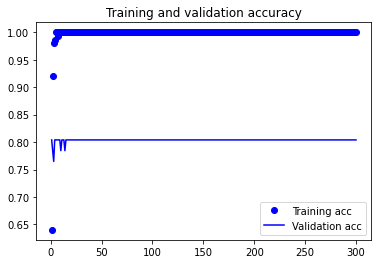

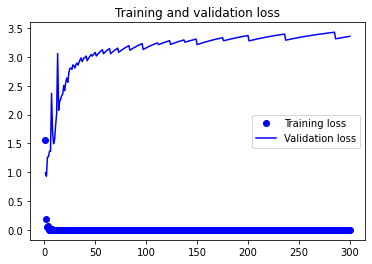

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

We can also try to train the same model without loading the pre-trained word embeddings and without freezing the embedding layer. In that
case, we would be learning a task-specific embedding of our input tokens, which is generally more powerful than pre-trained word embeddings
when lots of data is available. However, in our case, we have only 200 training samples. Let's try it:

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, 300, 100)          1000000   
                                                                 
 flatten_5 (Flatten)         (None, 30000)             0         
                                                                 
 dense_8 (Dense)             (None, 32)                960032    
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,960,065
Trainable params: 1,960,065
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
5/5 [==============================] - 1s 50ms/step - loss: 0.6753 - acc: 0.6800 - val_loss: 0.5435 - val_acc: 0.8039
Epoch 2/10
5/5 [==============================]

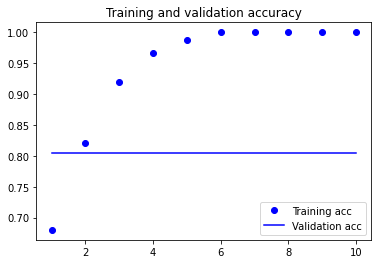

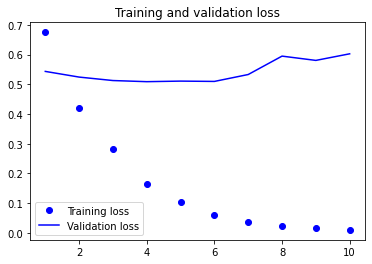

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# On your own
Finally, you can evaluate the model on the test data. First, we will need to tokenize the test data:

In [ ]:

# test_dir = os.path.join(imdb_dir, 'test')

# labels = []
# texts = []

# for label_type in ['neg', 'pos']:
#     dir_name = os.path.join(test_dir, label_type)
#     for fname in sorted(os.listdir(dir_name)):
#         if fname[-4:] == '.txt':
#             f = open(os.path.join(dir_name, fname))
#             texts.append(f.read())
#             f.close()
#             if label_type == 'neg':
#                 labels.append(0)
#             else:
#                 labels.append(1)

# sequences = tokenizer.texts_to_sequences(texts)
# x_test = pad_sequences(sequences, maxlen=maxlen)
# y_test = np.asarray(labels)

And let's load and evaluate the first model:

In [ ]:
# this model is saved on the left menu
# model.load_weights('pre_trained_glove_model.h5')
# model.evaluate(x_test, y_test)

We get an appalling test accuracy of 54%. Working with just a handful of training samples is hard!